In [98]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
#!MODELS
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

df_original=pd.read_csv('dataset.csv')#spotify dataset
df=df_original.drop(columns=['n','track_id','artists','album_name','track_name'])
df.explicit=df.explicit.astype('int')


df=df[df.track_genre.isin(['acoustic','classical','electronic','electro','guitar','k-pop','study','turkish'])]
df
x=df.iloc[:,:15]
y=df.iloc[:,-1]
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=12)
#more imports
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
pipe1=make_pipeline(StandardScaler(),KNeighborsClassifier(n_neighbors=7))
pipe2=make_pipeline(StandardScaler(),LogisticRegression(random_state=12))
pipe3=make_pipeline(StandardScaler(),DecisionTreeClassifier(max_depth=5,random_state=12))
pipe4=make_pipeline(StandardScaler(),RandomForestClassifier(random_state=12))
pipelines={
    'knn':pipe1,
    'logr':pipe2,
    'dtree':pipe3,
    'rfc':pipe4
}
results_score=[]
results_cvscore=[]
for name,pipe in pipelines.items():
    print(f"{name} with accuracy: {(pipe.fit(x_train,y_train).score(x_test,y_test)*100):.2f}%, CVScore: {(cross_val_score(pipe,x,y,cv=10).mean()*100):.2f}%")
    results_score.append(round(pipe.fit(x_train,y_train).score(x_test,y_test)*100,2))
    results_cvscore.append(round((cross_val_score(pipe,x,y,cv=10).mean()*100),2))
report=classification_report(y_test,pipe4.fit(x_train,y_train).predict(x_test))
print(report)


knn with accuracy: 61.70%, CVScore: 61.06%
logr with accuracy: 58.10%, CVScore: 57.79%
dtree with accuracy: 65.00%, CVScore: 59.56%
rfc with accuracy: 78.30%, CVScore: 73.96%
              precision    recall  f1-score   support

    acoustic       0.67      0.72      0.69       232
   classical       0.94      0.92      0.93       236
     electro       0.78      0.77      0.78       255
  electronic       0.67      0.64      0.66       247
      guitar       0.79      0.78      0.78       260
       k-pop       0.75      0.75      0.75       251
       study       0.88      0.92      0.90       250
     turkish       0.79      0.77      0.78       269

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000



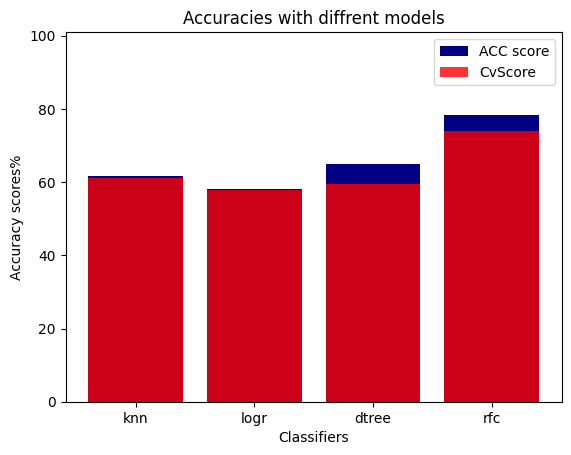

In [99]:
import matplotlib.pyplot as plt
plt.bar(pipelines.keys(),results_score,label='ACC score',color='navy')
plt.xlabel('Classifiers')
plt.ylabel('Accuracy scores%')
plt.title('Accuracies with diffrent models')
plt.ylim(0,101)
plt.bar(pipelines.keys(),results_cvscore,color='red',alpha=0.8,label='CvScore')
plt.legend()
plt.show()